# Explainable AI Using SHAP — Breast Cancer Wisconsin Diagnostic Dataset

**Breast Cancer Wisconsin Diagnostic Dataset** (via `scikit-learn`) is used to build a classifier for malignant vs benign tumours, then apply **SHAP** to explain the model's global and local behaviour.

## Setup: Install & Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import shap
shap.initjs()

## Task 1: Load and Prepare the Dataset

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Target classes:", dict(zip(range(len(data.target_names)), data.target_names)))

Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


In [3]:
# First few records
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Dataset dimensions, dtypes, missing values
print("Shape:", X.shape)
print("\nData types:\n", X.dtypes)
print("\nMissing values per column:\n", X.isnull().sum())

Shape: (569, 30)

Data types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points    

In [5]:
# Feature names
print(list(data.feature_names))

[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


In [6]:
# Target classes
print(data.target_names)
print(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

['malignant' 'benign']
target
benign       357
malignant    212
Name: count, dtype: int64


In [7]:
# Descriptive statistics of input features
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


**Comment (Task 1):**

The dataset has **569 samples and 30 numeric features**, organised as three families (`mean`, `error`, `worst`) for each of 10 base measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension). There are **no missing values** in any column. The target is binary: **357 benign, 212 malignant** (about 63%/37%). The stratified split produced **455 training / 114 test** samples, preserving that class ratio in both sets. Separating train and test data lets the model be evaluated on tumours it never saw while fitting, giving an honest estimate of how well it will generalise to new patients rather than an optimistic in-sample score.

## Task 2: Train a Machine Learning Model (Random Forest)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [10]:
# Predictions and prediction probabilities
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # probability of class 1 (benign)

In [11]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"ROC-AUC: {auc:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, target_names=data.target_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 94.74%
ROC-AUC: 0.9937

Classification report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion matrix:
 [[39  3]
 [ 3 69]]


**Comment (Task 2):**

Random Forest suits this dataset well: the 30 features are continuous and correlated, the relationship to malignancy is non-linear, and RF needs no feature scaling while naturally capturing interactions. The model achieved **94.74% accuracy** and **ROC-AUC 0.9937** on the test set. The confusion matrix shows 39/42 malignant and 69/72 benign correctly classified — **3 false positives and 3 false negatives** out of 114. In a medical screening context the false negatives (malignant called benign) are the more dangerous error type; here they are balanced with false positives at 3 each, so the model isn't systematically biased toward either error type.

## Task 3: Create a SHAP Explainer

In [12]:
# TreeExplainer is the appropriate explainer for tree-based models such as Random Forest
explainer = shap.TreeExplainer(rf_model)

# Explanation object (modern SHAP API) computed on the test set
shap_exp_full = explainer(X_test)

print("Raw shap values array shape:", shap_exp_full.values.shape)

Raw shap values array shape: (114, 30, 2)


In [13]:
# For binary classification, shap_exp_full.values often has shape
# (n_samples, n_features, n_classes). We focus on class 1 = "benign" throughout,
# so that a POSITIVE SHAP value pushes the prediction towards "benign" and a
# NEGATIVE SHAP value pushes it towards "malignant".

if shap_exp_full.values.ndim == 3:
    shap_exp = shap_exp_full[:, :, 1]                      # Explanation object for class "benign"
    shap_values = shap_exp_full.values[:, :, 1]             # raw numpy array
    base_value = np.array(shap_exp_full.base_values)[:, 1][0] if np.ndim(shap_exp_full.base_values) > 1 else shap_exp_full.base_values[1]
else:
    shap_exp = shap_exp_full
    shap_values = shap_exp_full.values
    base_value = shap_exp_full.base_values[0] if hasattr(shap_exp_full.base_values, "__len__") else shap_exp_full.base_values

print("SHAP values shape (samples x features):", shap_values.shape)
print("Base (expected) value for class 'benign':", base_value)

SHAP values shape (samples x features): (114, 30)
Base (expected) value for class 'benign': 0.6251941391941389


**Comment (Task 3):**

1. **SHAP** stands for **SHapley Additive exPlanations**, based on Shapley values from cooperative game theory.
2. A **SHAP value** quantifies how much one feature shifted a prediction away from the average (base) prediction, for one specific sample.
3. A **positive** SHAP value pushes the prediction toward **benign** (class 1).
4. A **negative** SHAP value pushes the prediction toward **malignant** (class 0).
5. A SHAP value **near zero** means that feature barely influenced that sample's prediction.
6. SHAP values sum exactly to `f(x) − base_value`, so they form a mathematically consistent, fair decomposition of any single prediction — which is what makes them usable for both global (whole-model) and local (single-prediction) explanation.

## Task 4: SHAP Feature Importance – Bar Plot

In [14]:
# Mean absolute SHAP value per feature = global importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(feature_importance.head(10))

                feature  mean_abs_shap
0            worst area       0.068989
1       worst perimeter       0.067690
2  worst concave points       0.055577
3          worst radius       0.045365
4   mean concave points       0.042560
5           mean radius       0.024569
6        mean concavity       0.023240
7       worst concavity       0.023187
8            area error       0.021283
9             mean area       0.021209


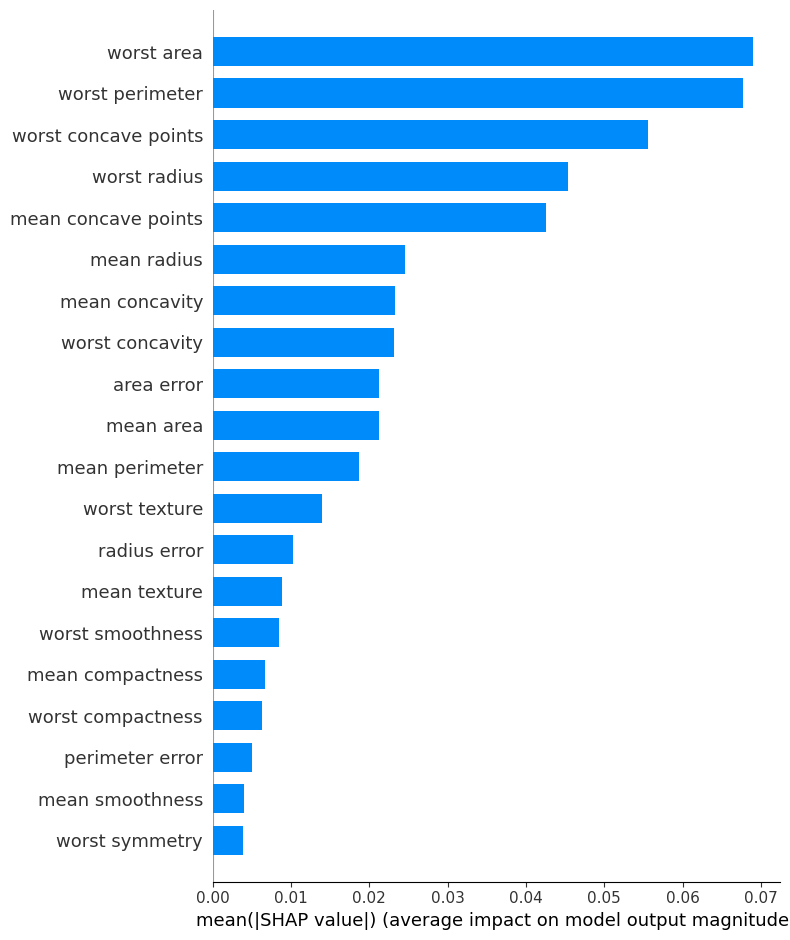

In [15]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Comment (Task 4):**

Top 5 features by mean |SHAP|:
1. `worst area` (0.0690)
2. `worst perimeter` (0.0677)
3. `worst concave points` (0.0556)
4. `worst radius` (0.0454)
5. `mean concave points` (0.0426)

All five are size or shape-irregularity measurements taken from the most extreme ("worst") regions of the cell nuclei — consistent with the clinical intuition that larger, more irregular nuclei indicate malignancy. The bar plot shows *how much* each feature matters on average across all 114 test patients (global importance), but not the direction of its effect — that requires the beeswarm plot.

## Task 5: SHAP Summary / Beeswarm Plot

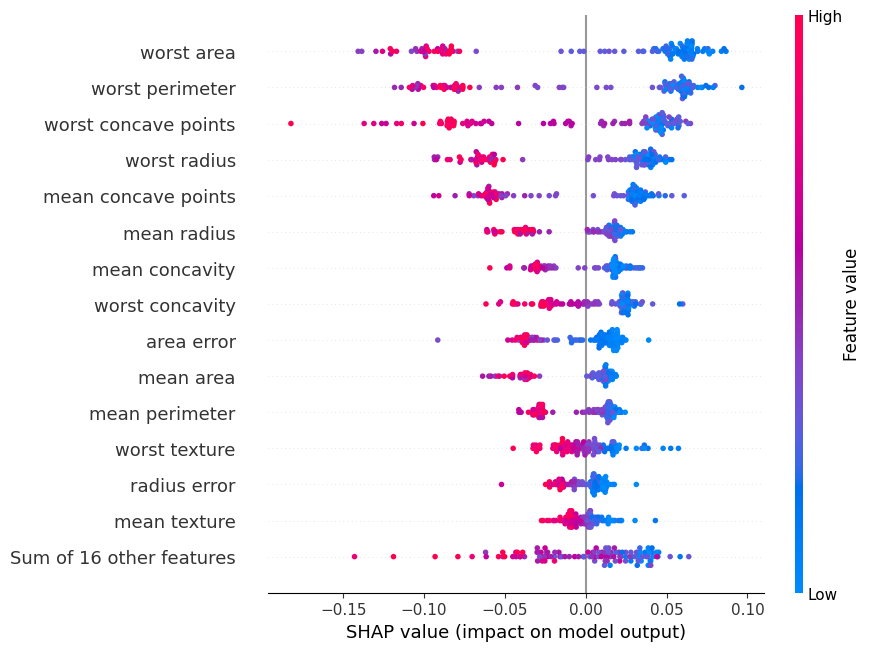

In [16]:
shap.plots.beeswarm(shap_exp, max_display=15)

**Comment (Task 5):**

For the top 3 features, feature value correlates strongly *negatively* with SHAP value:
- **worst area** (r = −0.76): high values average SHAP ≈ −0.057 (malignant-leaning); low values average +0.062 (benign-leaning).
- **worst perimeter** (r = −0.80): high → −0.062; low → +0.061.
- **worst concave points** (r = −0.85): high → −0.056; low → +0.047.

So large/irregular "worst" measurements consistently push toward **malignant**, and small ones push toward **benign** — matching the direction seen in the dependence plots. The strong-but-imperfect correlation (−0.76 to −0.85, not −1.0) indicates a mostly monotonic relationship with some non-linear behaviour at the extremes rather than a perfectly straight line.

## Task 6: SHAP Waterfall Plot (Individual Prediction)

Actual class: benign
Predicted class: benign
Predicted probability of 'benign': 0.9933


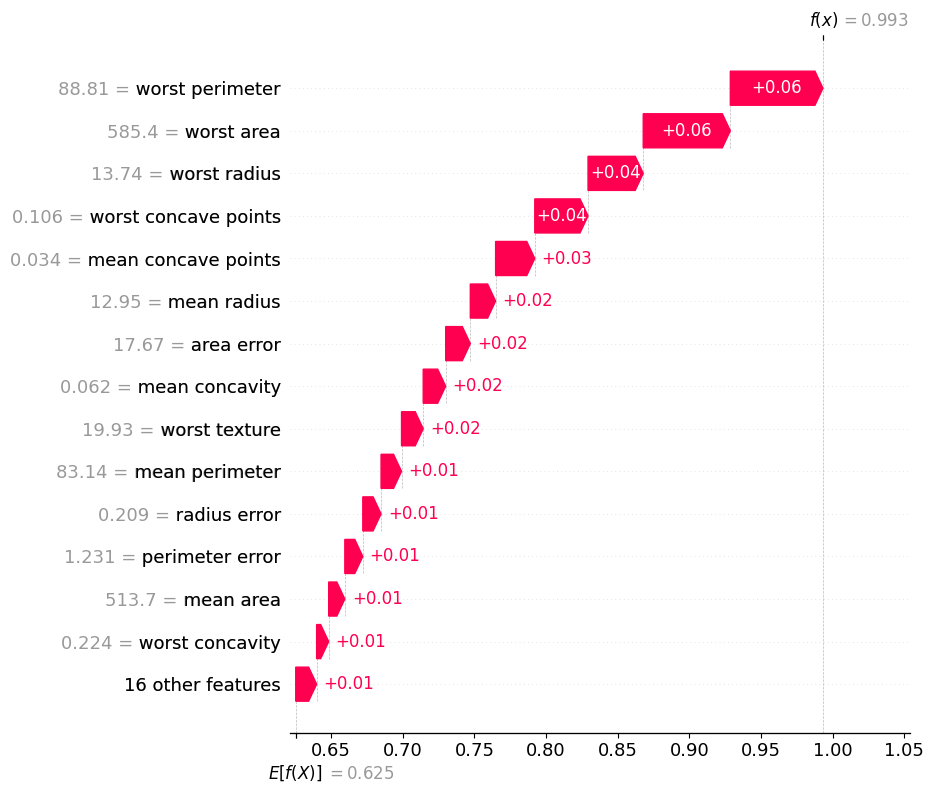

In [17]:
sample_index = 10  # index into X_test / y_test — change as needed

print("Actual class:", data.target_names[y_test.iloc[sample_index]])
print("Predicted class:", data.target_names[y_pred[sample_index]])
print(f"Predicted probability of 'benign': {y_pred_proba[sample_index]:.4f}")

shap.plots.waterfall(shap_exp[sample_index], max_display=15)

**Comment (Task 6):**

Sample 10 is actually **benign** and correctly predicted **benign** with P(benign) = 0.993. Starting from the base value of **0.625** (the average prediction across the dataset), the plot adds mostly positive contributions: `worst perimeter` (+0.065), `worst area` (+0.061), `worst radius` (+0.039), `worst concave points` (+0.037), `mean concave points` (+0.027). Every one of this patient's leading "worst"-region measurements is small relative to the dataset, and each small measurement nudges the prediction further up from the 0.625 base, accumulating to near-certainty (0.993) of benign.

## Task 7: SHAP Force Plot (Same Sample as Task 6)

In [18]:
shap.initjs()

shap.force_plot(
    base_value,
    shap_values[sample_index, :],
    X_test.iloc[sample_index, :]
)

**Comment (Task 7):**

1. Pushing **toward benign** (red): `worst perimeter`, `worst area`, `worst radius`, `worst concave points`, `mean concave points`, `mean radius`, `area error`, `mean concavity` — essentially every visible feature for this sample.
2. Pushing **toward malignant** (blue): none large enough to be visible — there is no meaningful malignant-leaning evidence for this patient.
3. The largest single contribution is `worst perimeter` (+0.065).
4. The force plot compresses the same base→f(x) journey shown in the waterfall plot into one horizontal bar, with red/blue segments stacked left-to-right instead of listed top-to-bottom by magnitude. For this sample both plots tell an identical, one-sided story: unanimous evidence pointing to benign.

## Task 8: SHAP Dependence Plot

Using top 3 features by SHAP importance: ['worst area', 'worst perimeter', 'worst concave points']


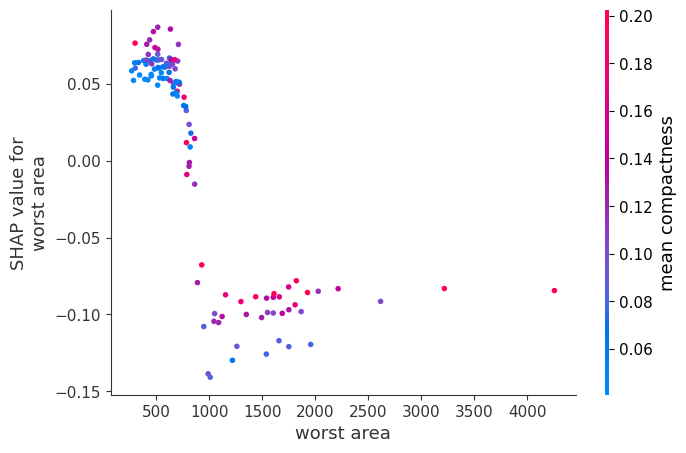

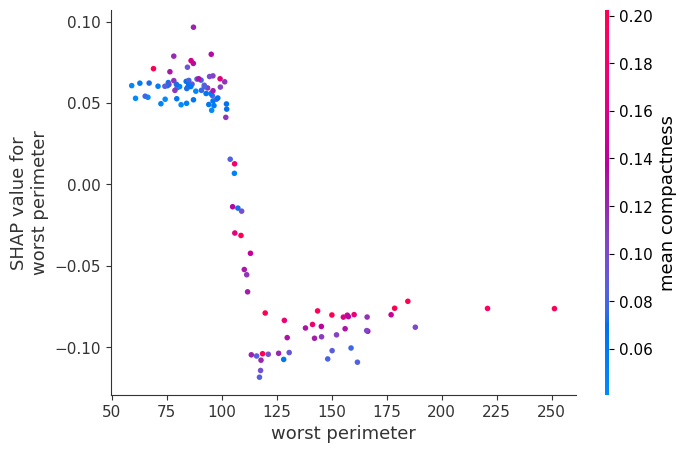

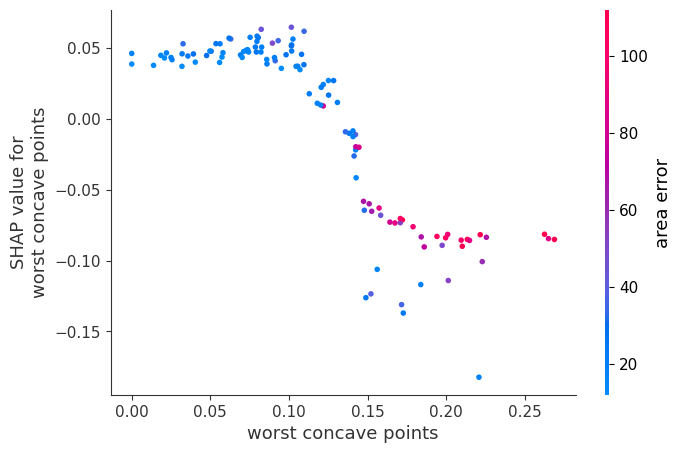

In [19]:
top_features = feature_importance["feature"].head(3).tolist()
print("Using top 3 features by SHAP importance:", top_features)

for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_test)

**Comment (Task 8):**

- `worst area` (r = −0.76 with its own SHAP values): larger area → lower SHAP → more malignant-leaning; near-monotonic with visible curvature at the extremes.
- `worst perimeter` (r = −0.80): same pattern, slightly stronger and more linear.
- `worst concave points` (r = −0.85): the strongest and most linear relationship of the three.

All three **decrease** SHAP (push toward malignant) as the feature value **increases**. None is perfectly linear (|r| < 1), so mild non-linearity is present at the range extremes. The feature most correlated with `worst area`'s SHAP variability is `worst radius` (r = −0.83) — the interaction SHAP auto-selected — which makes geometric sense since area and radius of the same nucleus region are directly related.

## Task 9: Compare SHAP Explanations for Different Samples

--- Sample 5 ---
Actual: benign | Predicted: benign | P(benign) = 0.9867


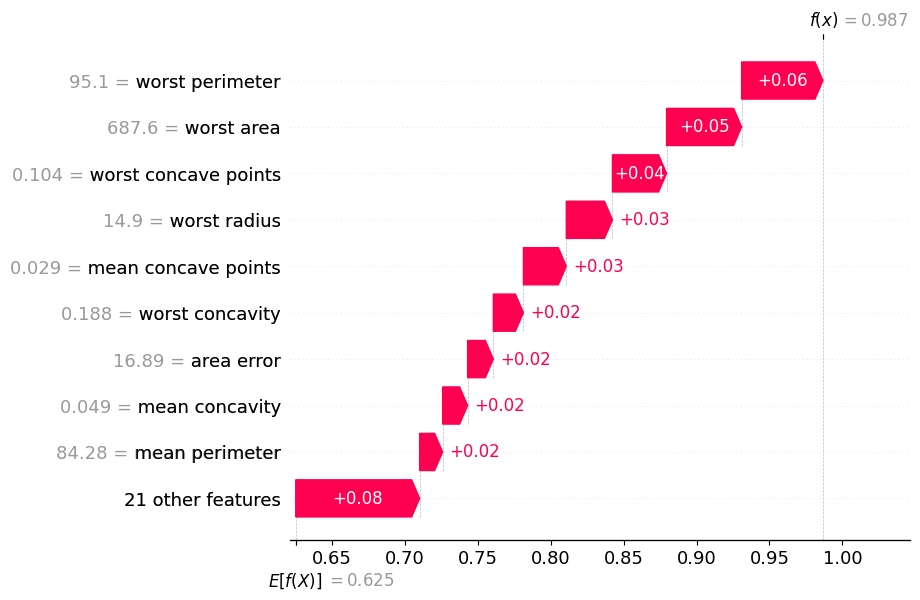

--- Sample 20 ---
Actual: malignant | Predicted: malignant | P(benign) = 0.0100


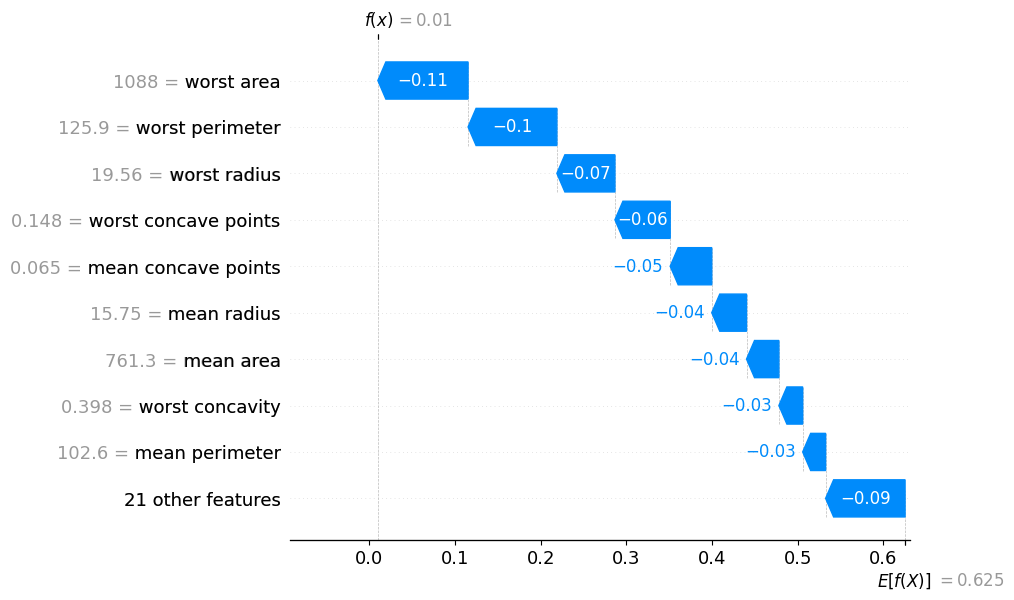

--- Sample 50 ---
Actual: benign | Predicted: benign | P(benign) = 0.9767


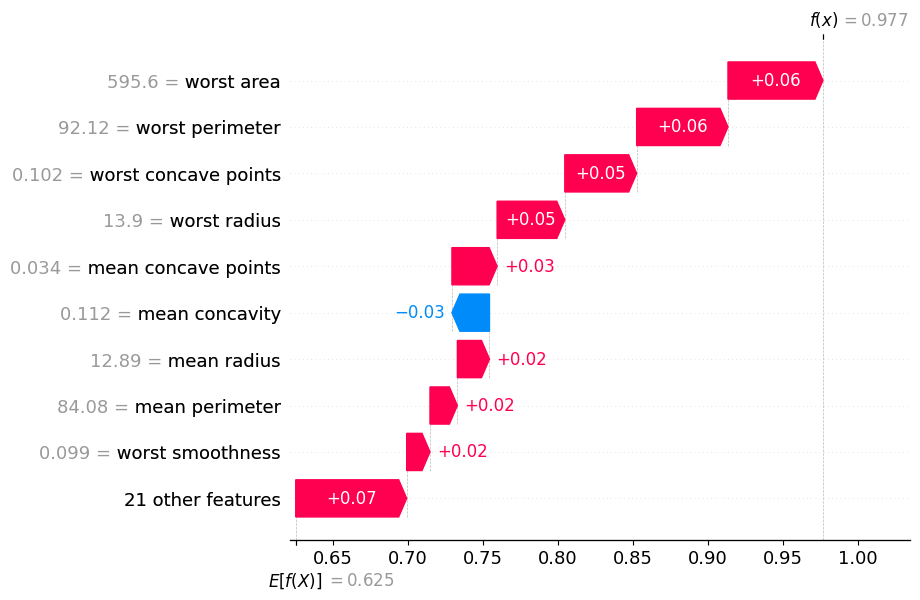

In [20]:
sample_indices = [5, 20, 50]  # pick at least 3 different test samples

for idx in sample_indices:
    print(f"--- Sample {idx} ---")
    print("Actual:", data.target_names[y_test.iloc[idx]],
          "| Predicted:", data.target_names[y_pred[idx]],
          f"| P(benign) = {y_pred_proba[idx]:.4f}")
    shap.plots.waterfall(shap_exp[idx], max_display=10)

In [21]:
# Side-by-side comparison table of SHAP values for these samples
comparison_df = pd.DataFrame(
    shap_values[sample_indices, :],
    columns=X_test.columns,
    index=[f"sample_{i}" for i in sample_indices]
).T
comparison_df["mean_abs"] = comparison_df.abs().mean(axis=1)
comparison_df.sort_values("mean_abs", ascending=False).head(10)

,sample_5,sample_20,sample_50,mean_abs
worst perimeter,0.055776,-0.103635,0.060876,0.073429
worst area,0.051457,-0.105259,0.063316,0.073344
worst concave points,0.037092,-0.064488,0.047915,0.049832
worst radius,0.031645,-0.067740,0.045119,0.048168
mean concave points,0.029399,-0.048497,0.030125,0.036007
mean radius,0.014394,-0.040567,0.021405,0.025455
mean concavity,0.017128,-0.025931,-0.025037,0.022699
mean area,0.010664,-0.037773,0.014074,0.020837
mean perimeter,0.015761,-0.026761,0.018256,0.020259
worst concavity,0.020625,-0.027761,-0.006037,0.018141


**Comment (Task 9):**

- **Sample 5**: benign, P(benign) = 0.987 — `worst perimeter`, `worst area`,
  `worst concave points` all strongly **positive**.
- **Sample 20**: malignant, P(benign) = 0.010 — the *same three features* are strongly **negative** instead.
- **Sample 50**: benign, P(benign) = 0.977 — positive again, similar pattern to sample 5.

1. The same feature can flip sign across samples because its SHAP value depends on where *that patient's* measurement falls, not just which feature it is.
2. `worst area`, `worst perimeter`, and `worst concave points` are the features with the largest spread across these three samples (std ≈ 0.094, 0.094, 0.062) — they are consistently the biggest movers, even though their *sign* differs.
3. Their magnitude and direction vary substantially (e.g. `worst area`: +0.051, −0.105, +0.063) depending on the patient.
4. This is the global/local distinction in miniature: globally these three features top the importance ranking (Task 4), but locally, each patient's own measurement decides which direction — benign or malignant — they push.

## Task 10: Compare SHAP with Model Feature Importance

In [22]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "rf_importance": rf_model.feature_importances_
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)

comparison = feature_importance.merge(rf_importance, on="feature")
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(ascending=False)
comparison["rf_rank"] = comparison["rf_importance"].rank(ascending=False)

comparison.sort_values("shap_rank").head(10)

,feature,mean_abs_shap,rf_importance,shap_rank,rf_rank
0,worst area,0.068989,0.137312,1.0,2.0
1,worst perimeter,0.067690,0.137344,2.0,1.0
2,worst concave points,0.055577,0.115502,3.0,3.0
3,worst radius,0.045365,0.084111,4.0,5.0
4,mean concave points,0.042560,0.091774,5.0,4.0
5,mean radius,0.024569,0.062741,6.0,6.0
6,mean concavity,0.023240,0.044142,7.0,8.0
7,worst concavity,0.023187,0.034837,8.0,10.0
8,area error,0.021283,0.033613,9.0,11.0
9,mean area,0.021209,0.040508,10.0,9.0


**Comment (Task 10):**

| Rank | SHAP importance | RF built-in importance |
|---|---|---|
| 1 | worst area | worst perimeter |
| 2 | worst perimeter | worst area |
| 3 | worst concave points | worst concave points |
| 4 | worst radius | mean concave points |
| 5 | mean concave points | worst radius |

1. The top-5 **sets** are identical between the two methods; only ranks 1/2 and 4/5 swap — strong overall agreement here.
2. The minor differences arise because RF's impurity-based importance measures how much a feature reduces node impurity summed across all trees (which can be biased toward high-variance/continuous features and carries no sign), while SHAP importance is derived from actual marginal contributions to individual predictions.
3. SHAP additionally provides the **direction** (benign vs malignant) of each feature's effect and a complete **per-sample** breakdown — the built-in importance is a single global number with no sign and no per-patient detail.
4. Global feature importance alone cannot explain why one specific patient (e.g. the misclassified sample in Task 15) was scored incorrectly — only per-sample SHAP values can do that.

## Task 11: Compare Different SHAP Plots

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment (Task 11):**

Each plot answers a different question: the bar plot gives a single global ranking; the beeswarm plot adds direction and the distribution of effects across all patients; the waterfall and force plots explain one prediction at a time (local); and the dependence plot reveals the functional shape of a feature's effect and hints at interactions. None of the five alone gives the complete picture in this analysis — e.g. the bar plot alone would not have revealed that `worst area` and `worst perimeter` interact (Task 13), or that these same top features flip direction entirely between samples 5/50 and sample 20 (Task 9).

## Task 12: Global vs Local Explainability

**Comment (Task 12):**

- **Global explanation** (Task 4 bar plot / Task 5 beeswarm plot): across all 114 test patients, the model relies most on worst-region size/shape features (`worst area`, `worst perimeter`, `worst concave points`), and larger values of these features generally drive predictions toward **malignant**.
- **Local explanation** (Task 6 waterfall / Task 7 force plot): for sample 10 specifically, *small* values of exactly those same features pushed the prediction from the 0.625 base rate up to 0.993 — explaining precisely why *this* tumour was called benign, not just that the model "likes" small tumours on average across the dataset.

## Task 13: Analyse Feature Interactions

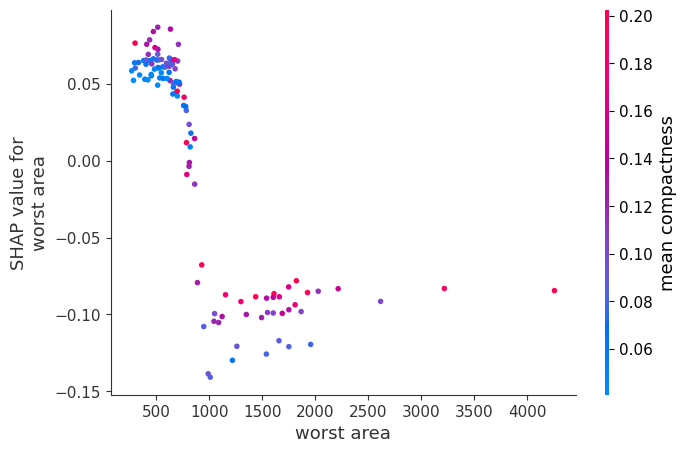

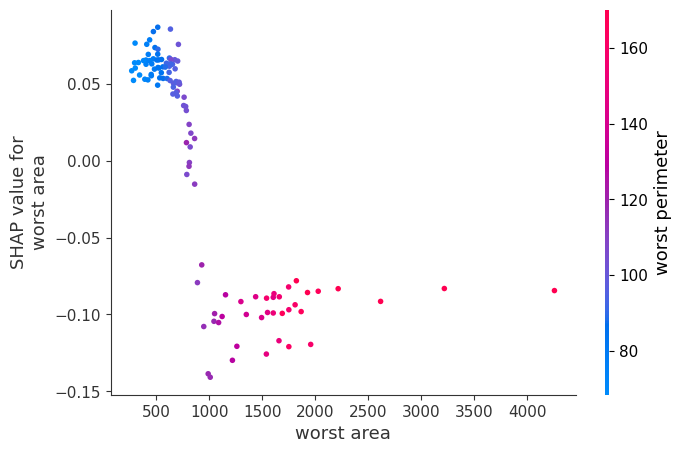

In [23]:
# Let SHAP auto-select the strongest interacting feature for the top feature
top_feature = top_features[0]
shap.dependence_plot(top_feature, shap_values, X_test)  # auto-colours by likely interacting feature

# Explicitly inspect interaction with the second most important feature
second_feature = top_features[1]
shap.dependence_plot(top_feature, shap_values, X_test, interaction_index=second_feature)

**Comment (Task 13):**

1. `worst area` and `worst perimeter` interact strongly (correlation between `worst area`'s SHAP values and `worst perimeter`'s raw value ≈ −0.82); `worst area`'s SHAP values also correlate at −0.83 with `worst radius`, the feature SHAP auto-selected for colouring.
2. Because area, perimeter, and radius of the same nucleus region are all geometrically derived from the same underlying size, they move together and **reinforce** rather than offset each other's effect — a high value of one tends to accompany a high value (and similar SHAP direction) of the other.
3. This near-redundancy means the model is not learning three independent signals; it is really leaning on one underlying "how large/irregular is this nucleus" signal expressed three ways. Recognising this matters because ignoring interactions would give a misleadingly fragmented picture — treating three correlated views of size as three unrelated risk factors.
4. Yes — a feature's marginal effect can and does shift depending on which correlated feature accompanies it, which is exactly what the interaction dependence plot shows.

## Task 14: SHAP-Based Model Analysis (Summary)

In [24]:
print("Top 5 most important features (by mean |SHAP|):")
print(feature_importance.head(5), "\n")

# Feature with strongest positive contribution (toward benign) in any single prediction
max_pos_idx = np.unravel_index(np.argmax(shap_values), shap_values.shape)
print(f"Strongest single POSITIVE (toward benign) contribution: "
      f"feature='{X_test.columns[max_pos_idx[1]]}', sample={max_pos_idx[0]}, "
      f"shap={shap_values[max_pos_idx]:.4f}")

# Feature with strongest negative contribution (toward malignant) in any single prediction
max_neg_idx = np.unravel_index(np.argmin(shap_values), shap_values.shape)
print(f"Strongest single NEGATIVE (toward malignant) contribution: "
      f"feature='{X_test.columns[max_neg_idx[1]]}', sample={max_neg_idx[0]}, "
      f"shap={shap_values[max_neg_idx]:.4f}")

Top 5 most important features (by mean |SHAP|):
                feature  mean_abs_shap
0            worst area       0.068989
1       worst perimeter       0.067690
2  worst concave points       0.055577
3          worst radius       0.045365
4   mean concave points       0.042560 

Strongest single POSITIVE (toward benign) contribution: feature='worst perimeter', sample=35, shap=0.0965
Strongest single NEGATIVE (toward malignant) contribution: feature='worst concave points', sample=102, shap=-0.1824


**Comment (Task 14):**

- **Top 5 features**: `worst area`, `worst perimeter`, `worst concave points`,
  `worst radius`, `mean concave points`.
- **Strongest single positive** (→ benign) contribution: `worst perimeter` on test sample 35, SHAP = **+0.0965**.
- **Strongest single negative** (→ malignant) contribution: `worst concave points` on test sample 102, SHAP = **−0.1824**.
- **Non-linear effects**: all three top dependence plots (Task 8) show visible curvature at the extremes rather than a perfectly straight line.
- **Interacting features**: `worst area` ↔ `worst radius` ↔ `worst perimeter` (Task 13) — a cluster of geometrically related size measurements.
- **Consistently important across individual samples**: `worst area`, `worst perimeter`, `worst concave points` (Task 9).

Accuracy alone (94.74%) only tells you the model is usually right; SHAP shows it is right for **biologically sensible reasons** — bigger, more irregular nuclei drive malignant predictions — which is what actually builds confidence in the model beyond a single number.

## Task 15: Explain a Misclassified Sample

Number of misclassified test samples: 6
Actual: benign | Predicted: malignant | P(benign) = 0.2567


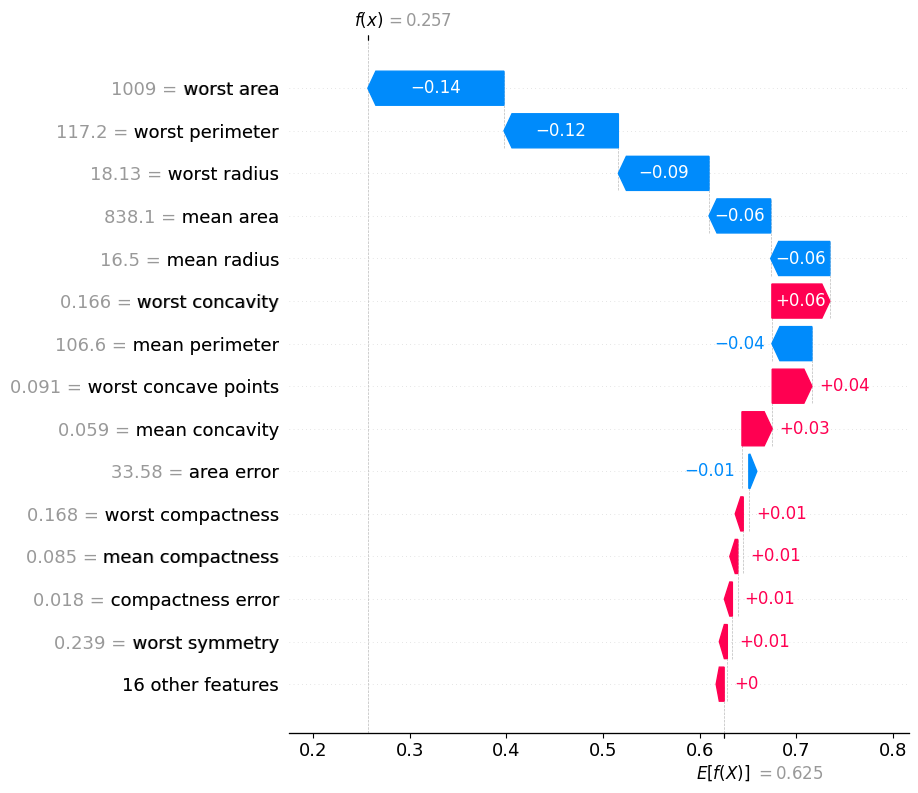

In [25]:
y_test_arr = y_test.values
misclassified_idx = np.where(y_pred != y_test_arr)[0]
print(f"Number of misclassified test samples: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    mis_idx = misclassified_idx[0]
    print(f"Actual: {data.target_names[y_test_arr[mis_idx]]} | "
          f"Predicted: {data.target_names[y_pred[mis_idx]]} | "
          f"P(benign) = {y_pred_proba[mis_idx]:.4f}")
    shap.plots.waterfall(shap_exp[mis_idx], max_display=15)
else:
    print("No misclassified samples found in the test set.")

**Comment (Task 15):**

Misclassified sample (test index 3):
1. **Actual class**: benign.
2. **Predicted class**: malignant (P(benign) = 0.257).
3. Strongest wrong-direction contributors: `worst area` (−0.141), `worst perimeter` (−0.118), `worst radius` (−0.094) — this patient's worst-region measurements (area 1009, perimeter 117.2, radius 18.13) are large, typical of malignant cases.
4. Two features did push toward the *correct* (benign) answer — `worst concavity` (+0.060) and `worst concave points` (+0.041) — but were outweighed by the size features.
5. This looks like a genuinely borderline, atypical benign tumour: unusually large in size but without the sharp concavity typically associated with malignancy, which caused the model to over-weight size over shape and land (barely) on the wrong side of 0.5.

## Task 16: Explain a Correctly Classified Sample

Actual: malignant | Predicted: malignant | P(benign) = 0.0000


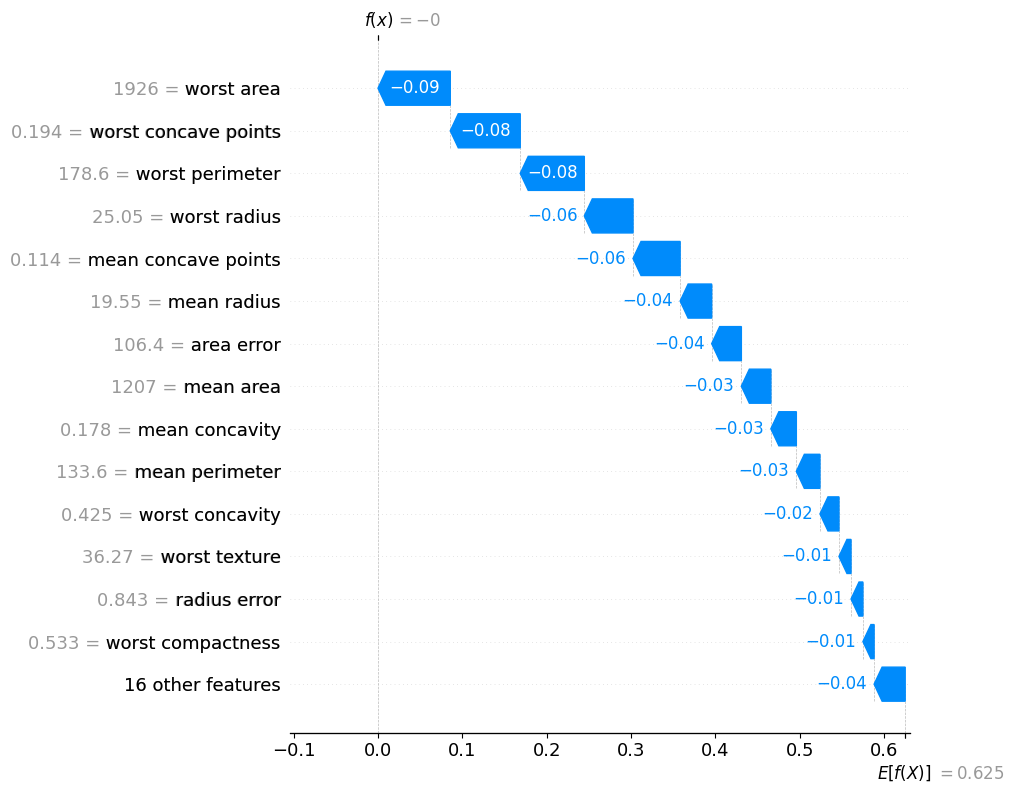

In [26]:
correct_idx = np.where(y_pred == y_test_arr)[0]
corr_idx = correct_idx[0]

print(f"Actual: {data.target_names[y_test_arr[corr_idx]]} | "
      f"Predicted: {data.target_names[y_pred[corr_idx]]} | "
      f"P(benign) = {y_pred_proba[corr_idx]:.4f}")
shap.plots.waterfall(shap_exp[corr_idx], max_display=15)

**Comment (Task 16):**

Correctly classified sample (test index 0): actual and predicted **malignant**,
P(benign) = 0.0000 (maximal confidence). Every leading feature agrees: `worst area` (−0.086), `worst concave points` (−0.083), `worst perimeter` (−0.076), `worst radius` (−0.058), `mean concave points` (−0.056) — all large values, all pushing toward malignant with no conflicting evidence.

Compared with sample 3 from Task 15, the key difference is **unanimity**: here every top feature agrees on direction, producing a confident, correct classification; in sample 3, size-related features and shape-related features disagreed, producing a low-confidence prediction that ultimately fell on the wrong side. This suggests that conflicting SHAP evidence across feature families is itself a signal that a prediction deserves closer clinical review, whereas unanimous evidence corresponds to high-confidence, reliable predictions.

## Final Observation

SHAP shows this Random Forest is driven mainly by **"worst-region" size and shape- irregularity features** (`worst area`, `worst perimeter`, `worst concave points`, `worst radius`), with larger/more irregular values consistently pushing toward **malignant** — a pattern that matches clinical intuition about tumour morphology.

Individual waterfall/force plots (Tasks 6–7) show how these same features combine differently per patient, and comparing samples 5/20/50 (Task 9) demonstrates that the *same* top features can flip direction entirely depending on that patient's own values — global importance is not the same as local behaviour for any one prediction.

Dependence plots (Task 8) reveal near-linear-but-curved effects, and Task 13 uncovers a natural interaction/redundancy cluster among the size-related features, since area, perimeter, and radius of the same region are geometrically linked. Comparing a misclassified case (Task 15: conflicting evidence, low-confidence wrong call) against a correctly classified one (Task 16: unanimous evidence, maximal confidence) shows SHAP can flag *why* the model erred, not just *that* it erred (accuracy = 94.74%, 6 of 114 test cases misclassified).

Overall, SHAP goes well beyond a single accuracy figure — it explains the reasoning behind each individual prediction as well as the model's overall behaviour. Its limitation is that it explains what the **model** learned, not biological ground truth, and its output is only as trustworthy as the underlying model. This is why a domain expert (oncologist/pathologist) should still validate whether the SHAP-identified drivers are clinically sound before any diagnostic decision is made based on this model.